# Research Paper Assistant — Exploratory Data Analysis

## Project Overview

The goal of this project is to develop an AI-powered research assistant
capable of retrieving and analyzing scientific papers.

This notebook focuses on exploring scientific paper data obtained from arXiv.
The analysis examines paper metadata and textual characteristics and prepares
the data for future NLP and retrieval tasks.

## Current Objectives

- Collect scientific paper metadata and text
- Break the data into chunks
- Analyze chunked data, make sure it has been processed correcly
- Configure a vector database as knowledge base
- Vectorize and upload the chunked data to the db
- Develop a base-model as a simple but full RAG architecure

The results of this analysis will later support the development of the
retrieval component of the Research Paper Assistant.

In [123]:
import xml.etree.ElementTree as ET
import os
import pymupdf
import re
import requests
from dotenv import load_dotenv
import json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from nltk.corpus import stopwords
import weaviate
from weaviate.classes.init import Auth
from transformers import AutoModelForCausalLM, AutoTokenizer
from IPython.display import display, Markdown
import pandas as pd



In [124]:
def download_arxiv_papers(max_results=100, folder="arxiv_papers"):
    os.makedirs(folder, exist_ok=True)

    url = "https://export.arxiv.org/api/query"

    params = {
        "search_query": "cat:cs.AI",
        "start": 0,
        "max_results": max_results,
        "sortBy": "submittedDate",
        "sortOrder": "descending",
    }

    response = requests.get(
        url,
        params=params,
        timeout=60
    )

    # Если arXiv вернул 4xx/5xx — сразу получим понятную ошибку
    response.raise_for_status()

    # response.content содержит XML в bytes
    root = ET.fromstring(response.content)

    ns = {
        "atom": "http://www.w3.org/2005/Atom"
    }

    articles = []

    for i, entry in enumerate(root.findall("atom:entry", ns)):
        title = entry.find("atom:title", ns).text.strip()
        abstract = entry.find("atom:summary", ns).text.strip()
        published = entry.find("atom:published", ns).text
        arxiv_url = entry.find("atom:id", ns).text

        arxiv_id = arxiv_url.split("/")[-1]

        pdf_url = f"https://arxiv.org/pdf/{arxiv_id}"

        pdf_path = os.path.join(
            folder,
            f"{arxiv_id.replace('/', '_')}.pdf"
        )

        print(f"[{i + 1}/{max_results}] {title}")
        try:
            pdf_response = requests.get(
                pdf_url,
                timeout=60
            )

            pdf_response.raise_for_status()

            with open(pdf_path, "wb") as f:
                f.write(pdf_response.content)

            print("downloaded")

        except requests.RequestException as e:
            print(f"ERROR: {e}")
            continue

        articles.append({
            "article_id": arxiv_id,
            "title": title,
            "abstract": abstract,
            "published_at": published,
            "url": arxiv_url,
            "pdf_path": pdf_path
        })
    json_path = os.path.join(folder, "articles.json")

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(
            articles,
            f,
            ensure_ascii=False,
            indent=4
        )

    print(f"Metadata saved to {json_path}")

    return articles

<font color = "red"> KEEP THIS FUNCTION CALL COMMENTED OUT! </font>

In [125]:
# articles = download_arxiv_papers()

<font color="red">__________________</font>

Arxive api returns the articles in the .pdf format, .html would be more suitable for this task, but it looks like the .html format is experimental and I decided to proceed with the more stable approach - use .pdf and then parse them into texts.

In [126]:
def pdf_to_text(articles):
    article_images = []
    parsed_articles = []

    os.makedirs("images", exist_ok=True)

    for article in articles:
        doc = pymupdf.open(article["pdf_path"])
        pages = []

        for page_nm, page in enumerate(doc, start=1):
            text = page.get_text()
            pages.append(text)

            images = page.get_images(full=True)

            if images:
                for image_nm, image in enumerate(images):
                    xref = image[0]

                    image_data = doc.extract_image(xref)
                    image_bytes = image_data["image"]
                    extension = image_data["ext"]

                    image_path = os.path.join(
                        "images",
                        f"{article['article_id']}_page_{page_nm}_image_{image_nm}.{extension}"
                    )

                    with open(image_path, "wb") as f:
                        f.write(image_bytes)

                    print(f"Image saved: {image_path}")

                    article_images.append({
                        "article_id": article["article_id"],
                        "page": page_nm,
                        "image_path": image_path
                    })

        doc.close()

        parsed = {
            "article_id": article["article_id"],
            "title": article["title"],
            "pdf_path": article["pdf_path"],
            "abstract": article["abstract"],
            "content": "\n".join(pages)
        }
        parsed_articles.append(parsed)

    # Save images metadata
    images_json_path = os.path.join("images", "images.json")

    with open(images_json_path, "w", encoding="utf-8") as f:
        json.dump(
            article_images,
            f,
            ensure_ascii=False,
            indent=4
        )

    # Save parsed articles
    with open("parsed_articles.json", "w", encoding="utf-8") as f:
        json.dump(
            parsed_articles,
            f,
            ensure_ascii=False,
            indent=4
        )

    return parsed_articles

<font color = "red" > KEEP THIS FUNCTION CALL COMMENTED OUT! </font>

In [127]:
# parsed_art = pdf_to_text(articles)

<font color="red"> ________ </font>

I will parse the .pdf files saving the images as well in case if I also want to add image processing to my project. I don't know how I will use it but for now I think it makes sense to map the images to the articles they've been extracted from:
arxive_papers/2609.30205v1.pdf
images/article_id_page#.png (2609.30205v1_10.png)

Since the images contain the description text and their number within the article, I think I will not be complicated to extract this information and map it with the information in the text chunks.

I have researched the libraries that perform chunking, perhaps I will use them later if I realise that I need a smarter chunking algorithm, but for now, in order not to clutter the project with extra libraries, I will use hand-coded fixed chunking approach. I have copied these functions from the Weaviate documentation since I am going to use it as my knowledge base.
https://weaviate.io/blog/chunking-strategies-for-rag

The chunk size and overlap will be adjusted later based on the available LLM context window and perfornmce analyses.

I am not going to do lemmatization/stemming since the text retrieved from the knowledge base is going to be added to the prompt for the main LLM. It has to be grammatically correct to have better context understanding.

In [128]:
def word_splitter(text):
    text = re.sub("\\s+", " ", text)
    return re.split("\\s", text)  # Split by single whitespace

def get_chunks_fixed_size_with_overlap(article, chunk_size, overlap_fraction):
    text_words = word_splitter(article["content"])
    overlap_int = int(chunk_size * overlap_fraction)
    chunks = []
    step = chunk_size - overlap_int
    count = 1
    for i in range(0, len(text_words), step):
        chunk_words = text_words[i:i + chunk_size]
        chunk = {
            "article_id": article["article_id"],
            "title": article["title"],
            "chunk_index": count,
            "text": chunk_words
        }
        count = count + 1
        chunks.append(chunk)
    return chunks

 I was not sure what to do with articles' abstract. On one hand, they might be too big to be retrieved as a whole and the article already contains the information of its abstract. On the other hand, abstract is a good semantic compression of the entire article, it could be useful during the retrieval process. For now, my decision is not to store it in the db, but, perhaps, later, I will add a separate embedding for the abstract.

I want to persist the text to a file so I don’t depend on in-memory variables and build my data frame from the file.

In [129]:
with open("parsed_articles.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [130]:
def prepare_data(df):
    db_ready_data = []
    for index, row in df.iterrows():
        article = row.to_dict()
        chunked_article = get_chunks_fixed_size_with_overlap(article, 110, 0.1)
        db_ready_data.extend(chunked_article)
    return db_ready_data

In [131]:
data_to_upload = prepare_data(df)

In [132]:
temp_data_df = pd.DataFrame(data_to_upload)
temp_data_df

,article_id,title,chunk_index,text
0,2609.31619v1,Learning to Stop without Learning to Stop: Sel...,1,"[Preprint., LEARNING, TO, STOP, WITHOUT, LEARN..."
1,2609.31619v1,Learning to Stop without Learning to Stop: Sel...,2,"[we, fine-tune, reasoning, models, to, predict..."
2,2609.31619v1,Learning to Stop without Learning to Stop: Sel...,3,"[that, explicitly, optimize, for, shorter, rea..."
3,2609.31619v1,Learning to Stop without Learning to Stop: Sel...,4,"[directly, Our, approach, Teach, confidence,, ..."
4,2609.31619v1,Learning to Stop without Learning to Stop: Sel...,5,"[et, al.,, 2025),, or, an-, swer, stability, (..."
...,...,...,...,...
10680,2609.30941v1,Spackle: Completing Large View Single Image NV...,70,"[enabled, with, patience, 10, and, a, minimum,..."
10681,2609.30941v1,Spackle: Completing Large View Single Image NV...,71,"[pixel, p, belongs, to, a, hole, region., The,..."
10682,2609.30941v1,Spackle: Completing Large View Single Image NV...,72,"[regions, already, explained, by, the, base, m..."
10683,2609.30941v1,Spackle: Completing Large View Single Image NV...,73,"[image,, it, may, also, be, misused, to, gener..."


In [133]:
chunks_per_article = (
    temp_data_df.groupby("article_id")
      .size()
      .reset_index(name="chunk_count")
)
print(f"Mean chunk count: {chunks_per_article['chunk_count'].mean():.2f}")
print(f"Maximum chunk count {chunks_per_article['chunk_count'].max():.2f}")
print(f"Minimum chunk count {chunks_per_article['chunk_count'].min():.2f}")

Mean chunk count: 107.93
Maximum chunk count 339.00
Minimum chunk count 22.00


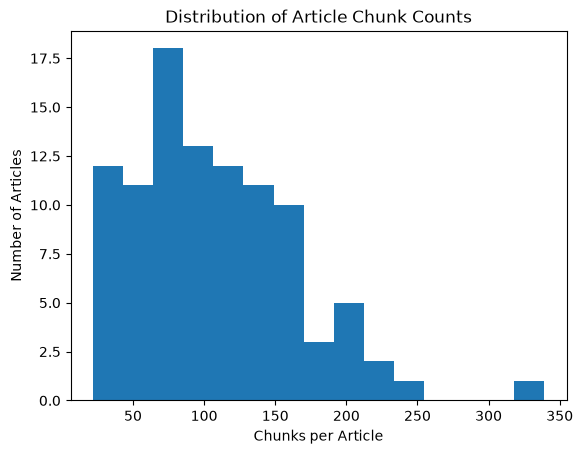

In [134]:
plt.hist(chunks_per_article["chunk_count"], bins=15)
plt.xlabel("Chunks per Article")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Chunk Counts")
plt.show()

The chunk counts per article look normal, as expected. The minum chunk count is 22 and the maximum 108, both numbers make sense. Interesting to notice that distribution of article chunk counts is skewed. Most of the articles are broken down into 50-100 chunks.

I have created the dataset by myself, it should not contain any duplicates or missing values. However, we can add these check to make sure that the dataframe was fomred correclty.

In [135]:
print("Missing values:")
print(df.isnull().sum())

print("Duplicate articles:")
print(df.duplicated(subset=["article_id"]).sum())


Missing values:
article_id    0
title         0
pdf_path      0
abstract      0
content       0
dtype: int64
Duplicate articles:
0


In [136]:
chunks = temp_data_df["text"]
all_text = []
for chunk in chunks:
    all_text.extend(chunk)

In [137]:
def generate_packed_coordinates(num_bubbles):
    coords = []
    theta = 0.0
    for i in range(num_bubbles):
        r = np.sqrt(i + 1) * 3.0  # Controls outer spread boundary
        theta += 0.5 + 4.0 / (i + 1)  # Progressive spacing angle
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        coords.append((x, y))
    return coords

In [138]:
def plot_bubble_chart(words, number_of_bubbles):
    word_counts = Counter(words)
    top_words = word_counts.most_common(number_of_bubbles)
    labels, counts = zip(*top_words)
    max_count = max(counts)
    max_bubble_area = 5000
    positions = generate_packed_coordinates(len(labels))
    x = [p[0] for p in positions]
    y = [p[1] for p in positions]
    bubble_sizes = [(c / max_count) * max_bubble_area for c in counts]
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(labels)))

    scatter = ax.scatter(x, y, s=bubble_sizes, c=colors, alpha=0.6, edgecolors="grey", linewidth=1.5)

    for i, (txt, count) in enumerate(zip(labels, counts)):
        ax.text(x[i], y[i], f"{txt}\n({count})",
                ha='center', va='center', fontsize=10, weight='normal')


    ax.set_title("Word Count Bubble Chart", fontsize=14, weight='bold', pad=20)
    ax.axis('off')
    ax.set_aspect('equal')
    plt.show()

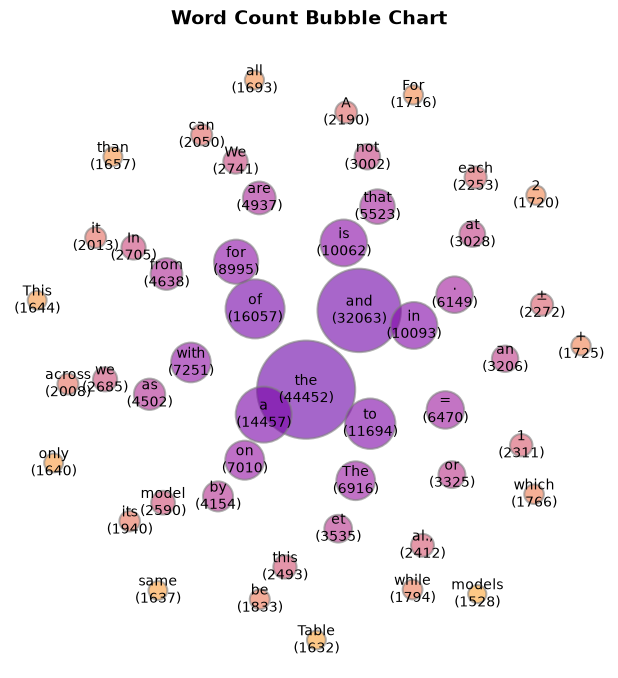

In [139]:
plot_bubble_chart(all_text, 50)

From this bubble chart of raw combined text we see the 50 most common words in all the articles. As expected these are mostly stop words (articles, prepositions etc... ) Now I will try to visualize the count of the meaningful words.

In [140]:
def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    big_words = []
    for word in text:
        world_clean = word.lower()
        if world_clean not in stop_words:
            big_words.append(world_clean)
    return big_words


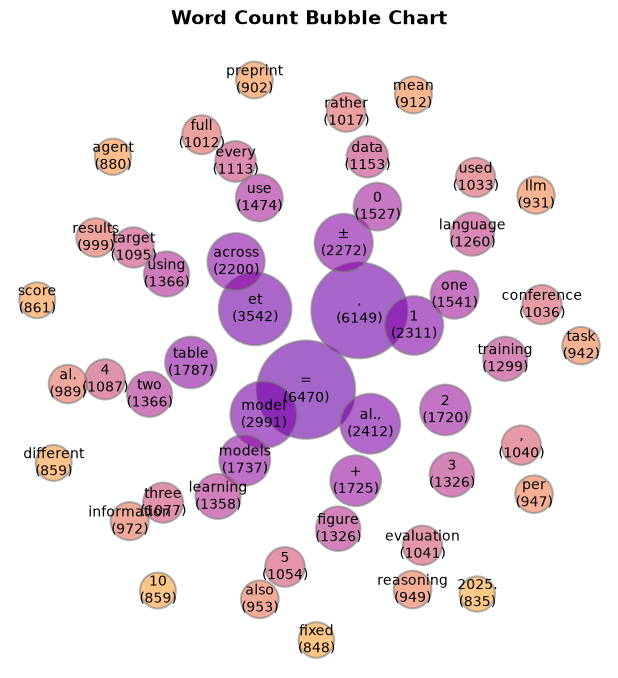

In [141]:
no_swtop_w = remove_stop_words(all_text)
plot_bubble_chart(no_swtop_w, 50)

After removing the stop words using the nltk library, I still see some words that might create noise, like '=' sign whihc now occupies the biggest bubble, and other math operation signs. But I am not sure if it is a good idea to remove them. I will leave them for now, but I will make a note that they can potentially be a reason for noise.

I want to keep to dataframes one with stop words another one clean and experiment with each.

In [142]:
temp_data_df_clean = temp_data_df.copy(deep=True)
temp_data_df_clean["text"] = temp_data_df_clean["text"].apply(remove_stop_words)

For the base model I will upload my full data frame (with stop words) to the knowledge base. The code below was taken from the weaviate website and adjusted to my project.

In [143]:
def upload_to_db(data):
    load_dotenv()
    weaviate_url = os.environ["WEAVIATE_URL"]
    weaviate_api_key = os.environ["WEAVIATE_API_KEY"]

    client = weaviate.connect_to_weaviate_cloud(
        cluster_url=weaviate_url,
        auth_credentials=Auth.api_key(weaviate_api_key),
    )

    client_connected = client.is_ready()
    if client_connected:
        try:
            collection = client.collections.use("Articles")
            response = collection.data.ingest(data)
            if response.has_errors:
                print(response.errors)
            else:
                print(f"Successfully uploaded all {len(data)} objects into the 'Articles' collection.")
        except Exception as e:
            print(e)

    client.close()

<font color="red">KEEP THIS FUNCTION CALL COMMENTED OUT</font>

In [144]:
#upload_to_db(data_to_upload)

<font color="red">________________</font>

I am using a local LLM model to have better control over my system. the code below was taken from the this recourse: https://huggingface.co/Qwen/Qwen3-8B?utm_source=chatgpt.com and adjected to my current needs.

In [145]:
def load_model():
    model_name = "Qwen/Qwen3-8B"
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype="auto",
        device_map="auto",
        local_files_only=True #swith it off to download from hugging face if you don't have it locally
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
    return {"model": model, "tokenizer": tokenizer}


In [146]:
def generate(model, tokenizer, prompt):
    messages = [
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
    print("Input tokens:", model_inputs["input_ids"].shape[1])
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens= 500
    )
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
    answer = tokenizer.decode(
        output_ids,
        skip_special_tokens=True
    )

    return answer


In [147]:
model_and_tokenizer = load_model()

Loading weights: 100%|██████████| 399/399 [00:04<00:00, 90.54it/s]


In [148]:
model = model_and_tokenizer["model"]
tokenizer = model_and_tokenizer["tokenizer"]

The topic is this article 2609.311619v1.pdf is easier for me to understand since it's purely DataScience and ML. I am going to use this article for tests. I have asked ChatGPT to generate a question regrading this article and I am going to feed this question to the downloaded model.

In [149]:
prompt = """
Can training a large language model to predict its confidence make its reasoning more efficient without explicitly optimizing for shorter reasoning?
Explain how this might work.
"""
answer = generate(model, tokenizer, prompt)

Input tokens: 41


In [150]:
display(Markdown(answer))

Yes, training a large language model (LLM) to predict its own confidence can **indirectly make its reasoning more efficient** without explicitly optimizing for shorter reasoning. This is because confidence prediction can act as a **meta-cognitive signal** that influences how the model processes information and allocates computational resources.

---

### 🔍 **How Confidence Prediction Might Improve Reasoning Efficiency**

#### 1. **Meta-Cognitive Awareness**
When a model is trained to predict its own confidence, it learns to **assess the reliability of its outputs**. This awareness can lead to more **strategic reasoning**, where the model:
- Allocates more computation to uncertain or complex tasks.
- Uses heuristics or shortcuts for well-understood or high-confidence tasks.
- Avoids unnecessary deep reasoning for problems it can solve quickly or confidently.

This is similar to how humans use intuition or heuristics to make decisions efficiently.

#### 2. **Reduced Overthinking**
Confidence prediction can help the model **avoid overthinking**. If the model learns that it can be confident in its answer without extensive reasoning, it may **stop early** and return a result, rather than continuing to process information unnecessarily.

This can lead to **faster response times** and **lower computational costs**, even without explicitly optimizing for shorter reasoning paths.

#### 3. **Improved Focus on Critical Steps**
By signaling when it is uncertain, the model may **prioritize critical steps** in its reasoning process. For example:
- It might **skip redundant checks** when it is confident in a premise.
- It might **reinforce weak links** in the reasoning chain when it is uncertain.

This selective attention can lead to more efficient use of cognitive resources, even if the overall reasoning path is not necessarily shorter.

#### 4. **Error Correction and Self-Consistency**
Confidence prediction can also **drive error correction**. If the model is uncertain about an intermediate step, it may re-examine or recompute that part of the reasoning. This can lead to **more robust reasoning** without explicitly optimizing for correctness, as the model is naturally incentivized to correct its own mistakes when it is uncertain.

#### 5. **Feedback Loop for Learning**
Confidence prediction can serve as a **feedback signal** for the model during training. If the model is trained to **minimize prediction error** in its confidence estimates, it learns to better distinguish between high- and low-confidence outputs. This can

Now I want to do the augmented search by retriving the information from my knowledge base using the vector similarity search. My mean chucnk count per an article is 107 but for the base line I will limit the retrieval to 20, just to see how the entire system works. Leter I will adjust this number and use a smarter system of document selection.

In [151]:
from weaviate.classes.query import MetadataQuery

def retrieve(prompt):
    load_dotenv()
    weaviate_url = os.environ["WEAVIATE_URL"]
    weaviate_api_key = os.environ["WEAVIATE_API_KEY"]
    docs = []

    client = weaviate.connect_to_weaviate_cloud(
        cluster_url=weaviate_url,
        auth_credentials=Auth.api_key(weaviate_api_key),
    )

    if client.is_ready():
        jeopardy = client.collections.use("Articles")
        response = jeopardy.query.near_text(
            query=prompt,
            limit=20,
            return_metadata=MetadataQuery(distance=True)
        )

        for o in response.objects:
            docs.append({"doc": o.properties, "distance": o.metadata.distance})
    client.close()
    return docs



In [152]:
docs = retrieve(prompt)


I am going to use Mean Average Precision (MAP) and Recall@K to evaluate the retrieval component. MAP measures how highly the expected article is ranked among the retrieved results, while Recall@K measures whether the expected article appears within the top K retrieved results.

In [153]:
retrieval_tests = [
    # Article 1
    {
        "question": "Can a model learn to use fewer computational resources during inference even when efficiency is never directly included in its training objective?",
        "expected_article_id": "2609.31619v1",
        "difficulty": "hard"
    },
    {
        "question": "Could teaching a system to better assess its own certainty indirectly change how much computation it uses to solve problems?",
        "expected_article_id": "2609.31619v1",
        "difficulty": "hard"
    },
    {
        "question": "Is explicitly rewarding shorter solutions necessary to make complex problem solving more computationally efficient?",
        "expected_article_id": "2609.31619v1",
        "difficulty": "hard"
    },

    # Article 2
    {
        "question": "How can the demographic composition of generated samples be controlled when the underlying generator cannot be modified?",
        "expected_article_id": "2609.31607v1",
        "difficulty": "hard"
    },
    {
        "question": "Can unwanted distributional biases in generated results be corrected solely by deciding which generated samples to keep?",
        "expected_article_id": "2609.31607v1",
        "difficulty": "hard"
    },
    {
        "question": "How could a user obtain generated samples with predetermined population proportions while treating the generator as an inaccessible system?",
        "expected_article_id": "2609.31607v1",
        "difficulty": "hard"
    },

    # Article 3
    {
        "question": "Does giving an autonomous programming system additional explanations of existing source files actually make it better at fixing repository problems?",
        "expected_article_id": "2609.31587v1",
        "difficulty": "hard"
    },
    {
        "question": "If a programming agent already sees the implementation, does providing a condensed explanation of that implementation improve its ability to solve issues?",
        "expected_article_id": "2609.31587v1",
        "difficulty": "hard"
    },
    {
        "question": "When describing software for later reconstruction, is preserving all important information more valuable than simply producing a longer explanation?",
        "expected_article_id": "2609.31587v1",
        "difficulty": "hard"
    },

    # Article 4
    {
        "question": "How can a 3D representation remain accurate when photographs of a rotating object were not taken at consistent rotational intervals?",
        "expected_article_id": "2609.31572v1",
        "difficulty": "hard"
    },
    {
        "question": "Can uncertain camera positions be corrected during reconstruction instead of assuming that the original capture positions are accurate?",
        "expected_article_id": "2609.31572v1",
        "difficulty": "hard"
    },
    {
        "question": "What approach could reconstruct an object from only a few rotational views when some expected frames are missing?",
        "expected_article_id": "2609.31572v1",
        "difficulty": "hard"
    },

    # Article 5
    {
        "question": "How does introducing interactive machine intelligence into lessons change the work teachers must do to support young students?",
        "expected_article_id": "2609.31569v1",
        "difficulty": "hard"
    },
    {
        "question": "What practical changes do educators make when a new intelligent conversational technology does not perfectly fit their students or lesson plans?",
        "expected_article_id": "2609.31569v1",
        "difficulty": "hard"
    },
    {
        "question": "How might educators mediate between the limitations of an interactive intelligent system, children's needs, and existing instructional goals?",
        "expected_article_id": "2609.31569v1",
        "difficulty": "hard"
    }
]

In [154]:
retrieval_asw = []
for item in retrieval_tests:
    retrieval_asw.append(retrieve(item["question"]))


In [155]:
def average_precision_at_k(docs, expected_article_id, k=5):
    docs = docs[:k]
    for rank, item in enumerate(docs, start=1):
        article_id = item["doc"]["article_id"]
        if article_id == expected_article_id:
            return 1.0 / rank
    return 0.0

def mean_average_precision(retrieval_tests, retrieval_answers, k=5):
    ap_scores = []
    for test, docs in zip(retrieval_tests, retrieval_answers):
        ap = average_precision_at_k(
            docs=docs,
            expected_article_id=test["expected_article_id"],
            k=k
        )
        ap_scores.append(ap)
    return sum(ap_scores) / len(ap_scores)

In [156]:
map = mean_average_precision(
    retrieval_tests,
    retrieval_asw,
    k=20
)


In [157]:
def recall_at_k(docs, expected_article_id, k=20):
    docs = docs[:k]
    retrieved_ids = [
        item["doc"]["article_id"]
        for item in docs
    ]
    return 1.0 if expected_article_id in retrieved_ids else 0.0

def mean_recall_at_k(retrieval_tests, retrieval_answers, k=5):
    recall_scores = []
    for test, docs in zip(retrieval_tests, retrieval_answers):
        recall = recall_at_k(
            docs=docs,
            expected_article_id=test["expected_article_id"],
            k=k
        )
        recall_scores.append(recall)
    return sum(recall_scores) / len(recall_scores)

In [158]:
recall_1 = mean_recall_at_k(
    retrieval_tests,
    retrieval_asw,
    k=1
)

recall_3 = mean_recall_at_k(
    retrieval_tests,
    retrieval_asw,
    k=3
)

recall_5 = mean_recall_at_k(
    retrieval_tests,
    retrieval_asw,
    k=5
)


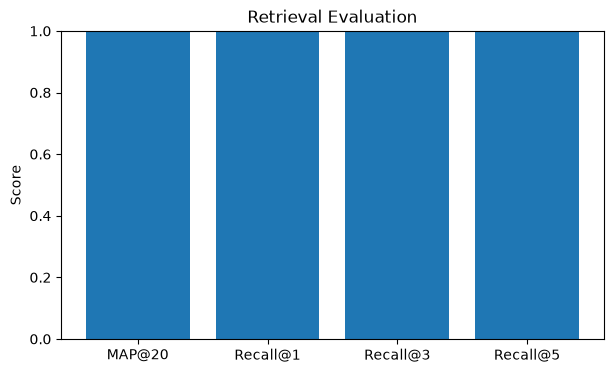

In [159]:
metrics = ["MAP@20", "Recall@1", "Recall@3", "Recall@5"]
scores = [map, recall_1, recall_3, recall_5]

plt.figure(figsize=(7, 4))
plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Retrieval Evaluation")
plt.show()

We can see perfect results. They can be explained by several facts:

- fact that the test questions were generated by the LLM and they are semantically very close to the articles
- I have a very small knowledge base, there's no competition between the vectors
Besides evaluating the results statistically, we can also have a subjective evaluation by reading an example of the generated answer by the RAG system.

In [160]:
def rag_generate(model, tokenizer, docs, input):
    context = ""
    for item in docs:
        context += f"""
        Title: {item['doc']['title']}
        Content:{item['doc']['text']}
        ---
    """

    prompt = f"""
        Answer the question using only the information provided in the context.
        If the context does not contain enough information to answer the question, say:
        "I don't have enough information in the provided context."
        Do not use information that is not supported by the context.
        Context:
        {context}
        Question:
        {input}
        Answer:
    """
    return generate(model, tokenizer, prompt)


In [161]:
answer = rag_generate(model, tokenizer, docs, prompt)

Input tokens: 8946


In [162]:
display(Markdown(answer))

Yes, training a large language model to predict its confidence can make its reasoning more efficient without explicitly optimizing for shorter reasoning. This approach, referred to as self-supervised confidence training, involves fine-tuning the model to predict its confidence in the answer at intermediate points along its own reasoning trajectories. The confidence is used solely as a training target, and the loss function does not include any objective for reasoning length, efficiency, or stopping.

The model learns to predict confidence based on its own token probabilities, without requiring gold correctness labels or external feedback. This self-supervised signal about the model's intermediate reasoning state allows it to implicitly learn when further computation is beneficial or unnecessary. As a result, the model's reasoning becomes more efficient, with substantial reductions in generated tokens at matched accuracy across various models and tasks. The efficiency gains are comparable to methods that explicitly optimize for shorter reasoning, yet the model does not directly learn to stop or shorten its reasoning. Instead, the learning of confidence reshapes the reasoning process toward greater efficiency as a downstream consequence.

Subjectivly, the RAG sytem also gives a good answer.
The most important part of the system is the LLM itself, which is also has to be evaluated. I am planning to use RAGAS library for evaluation of the entire system. It is going to create a synthetic evaluation dataset and use a judge-model to evalute my system.
However, RAGAS evaluation has not yet been completed due to the computational cost and complexity of generating a synthetic evaluation dataset. Test generation requires multiple LLM calls and embedding operations for each document, which makes the process time-consuming when using locally hosted models.

For the current evaluation, I therefore focused on the retrieval component of the RAG pipeline using metrics such as Mean Average Precision (MAP) and Recall@K. RAGAS-based evaluation of answer faithfulness and relevancy is planned as a next step.

The primary goal of this project was to design and implement the complete data flow for a functional RAG system, from data collection and preprocessing to vector storage, retrieval, and response generation.